In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm,LogNorm


import sunpy
import sunpy.map

from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
from astropy.wcs.utils import wcs_to_celestial_frame
from astropy.io import fits
import astropy.units as u

from skimage.registration import phase_cross_correlation
from sunkit_instruments.iris import SJI_to_sequence

import sys
sys.path.insert(0, '..')
from scripts.iris_prep_despike import iris_prep_despike


In [2]:
import scienceplots
plt.rcParams.update({'font.size': 14})
plt.style.use(['bright'])
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Avenir']

load SJI FITS into a Sunpy map sequence:

In [3]:
sji_fn = '/Users/willashfield/indirect_imaging/sji/iris_l2_20140418_123338_3820259153_SJI_1400_t000.fits'
sji_maps = SJI_to_sequence(sji_fn)

want to pull the SJI frame closest to our AIA map:

In [4]:
times = np.array([m.date for m in sji_maps])
datetimes = np.array([t.datetime for t in times])

aia_map = sunpy.map.Map('/Users/willashfield/indirect_imaging/aia_prep_1600_20140418_125216.fits')
tm_index = np.argmin(np.abs(datetimes-aia_map.date.datetime))
sji_map = sji_maps[tm_index]

subset our map to remove white edges

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


For frame 'heliographic_stonyhurst' the following metadata is missing: hgln_obs,hglt_obs
For frame 'heliographic_carrington' the following metadata is missing: crlt_obs,crln_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hgln_obs,hglt_obs
For frame 'heliographic_carrington' the following metadata is missing: crlt_obs,crln_obs
 [sunpy.map.mapbase]


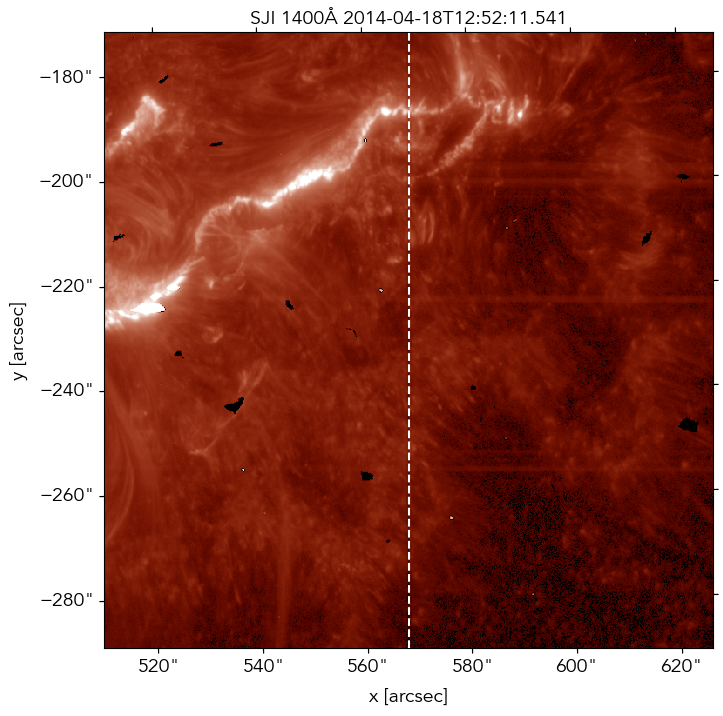

In [5]:
bl = (511*u.arcsec, -289*u.arcsec)
tr = (626*u.arcsec, -172.6*u.arcsec)

sub_map = sji_map.submap(SkyCoord(bl[0],bl[1],frame=sji_map.coordinate_frame), 
                      top_right=SkyCoord(tr[0],tr[1],frame=sji_map.coordinate_frame))

# also set negative (and small) values to 1.0 (mostly for plotting)
sub_map.data[sub_map.data < 1.0] = 1.0

# and plot
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection=sub_map)
sub_map.plot(axes=ax,norm=LogNorm(vmin=1.0))

ax.coords.grid(False)
ax.set_xlabel('x [arcsec]')
ax.set_ylabel('y [arcsec]')
ax.set_title(f"SJI 1400{chr(197)} {sji_map.date}",fontsize=14)

slit_px = sub_map.meta['crpix1']
ax.axvline(slit_px,color='white',linestyle='dashed')

want to despike our image: 

In [6]:
sji_data = sub_map.data
knl  = np.ones((15,15)) # found larger kernal needed here.

despiked_data = iris_prep_despike(sji_data, mode='bright',kernel = knl)

Mon Jul 13 14:49:21 2026 IRIS_PREP_DESPIKE started on array of 495600 elements.
Step (1): Iteratively identifying bad pixels.
Iteration    1 found          175 bad pixels,          175 of them new.
Iteration    2 found          278 bad pixels,          103 of them new.
Iteration    3 found          315 bad pixels,           37 of them new.
Iteration    4 found          331 bad pixels,           16 of them new.
Iteration    5 found          339 bad pixels,            8 of them new.
Iteration    6 found          341 bad pixels,            2 of them new.
Iteration    7 found          343 bad pixels,            2 of them new.
Iteration    8 found          344 bad pixels,            1 of them new.
Step (2): Replacing bad pixels
Mon Jul 13 14:49:24 2026 IRIS_PREP_DESPIKE finished, 2.8 sec elapsed.


create new map with despiked data:

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


For frame 'heliographic_stonyhurst' the following metadata is missing: hgln_obs,hglt_obs
For frame 'heliographic_carrington' the following metadata is missing: crlt_obs,crln_obs
 [sunpy.map.mapbase]


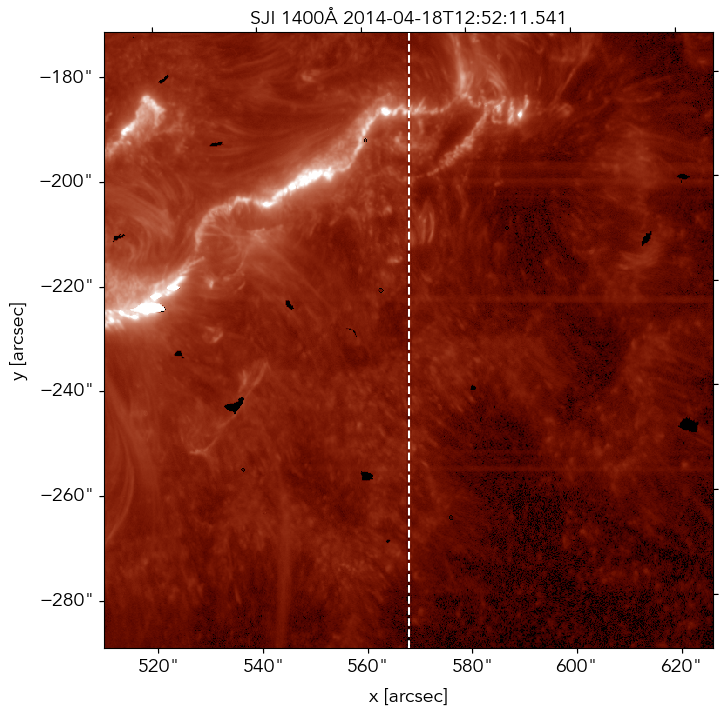

In [7]:
iris_map = sunpy.map.Map(despiked_data, sub_map.meta)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection=iris_map)
iris_map.plot(axes=ax,norm=LogNorm(vmin=1.0))

ax.coords.grid(False)
ax.set_xlabel('x [arcsec]')
ax.set_ylabel('y [arcsec]')
ax.set_title(f"SJI 1400{chr(197)} {sji_map.date}",fontsize=14)

slit_px = iris_map.meta['crpix1']
ax.axvline(slit_px,color='white',linestyle='dashed')

better! now we need to align our IRIS SJI frame to the AIA frame:

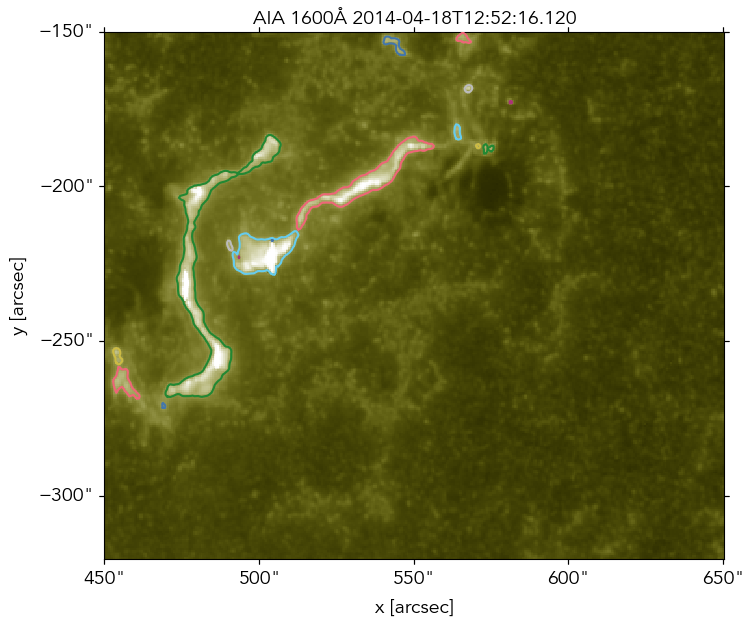

In [8]:
#sub-set our AIA map. slightly arbitrary choice here, but want the ribbons to be visible

bl = (450*u.arcsec, -320*u.arcsec)
tr = (650*u.arcsec, -150*u.arcsec)

amap = aia_map.submap(SkyCoord(bl[0],bl[1],frame=aia_map.coordinate_frame), 
                      top_right=SkyCoord(tr[0],tr[1],frame=aia_map.coordinate_frame))


%matplotlib inline

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection=amap)
amap.plot(axes=ax)

ax.coords.grid(False)
ax.set_xlabel('x [arcsec]')
ax.set_ylabel('y [arcsec]')

ax.set_title(f"AIA 1600{chr(197)} {amap.date}",fontsize=14)

a_ribbon = amap.find_contours(15e2 * u.DN/u.s)
for r in a_ribbon:
    ax.plot_coord(r)
plt.show()

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


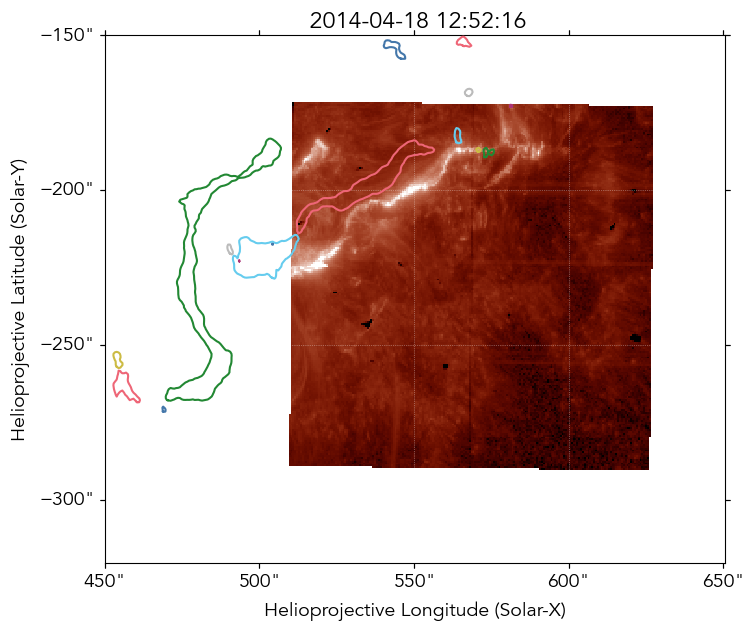

In [9]:
iris_reproj = iris_map.reproject_to(amap.wcs)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection=iris_reproj)
iris_reproj.plot(axes=ax,norm=LogNorm())


for r in a_ribbon:
    ax.plot_coord(r)
plt.show()

^ alignment clearly off.

In [10]:
# double check the shapes of the data arrays to make sure they match

aia_data = amap.data
iris_data = iris_reproj.data

print(f"AIA data shape: {aia_data.shape}")
print(f"IRIS data shape: {iris_data.shape}")

AIA data shape: (284, 334)
IRIS data shape: (284, 334)


In [11]:
img1 = aia_data; img2 = iris_data
img1[np.isnan(img1)] = 0; img2[np.isnan(img2)] = 0

shift = phase_cross_correlation(img1, # reference image
                                    img2, # moving image
                                    upsample_factor=10)
print('shift [y px, x px]: ',shift[0])

dy,dx = shift[0]*amap.meta['cdelt1']*u.arcsec
print('shift [y arc, x arc]: ',dy,dx)

shift [y px, x px]:  [  0.1 -25.2]
shift [y arc, x arc]:  0.06 arcsec -15.12 arcsec


In [12]:
iris_map = iris_map.shift_reference_coord(dx,dy)

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


For frame 'heliographic_stonyhurst' the following metadata is missing: hgln_obs,hglt_obs
For frame 'heliographic_carrington' the following metadata is missing: crlt_obs,crln_obs
 [sunpy.map.mapbase]


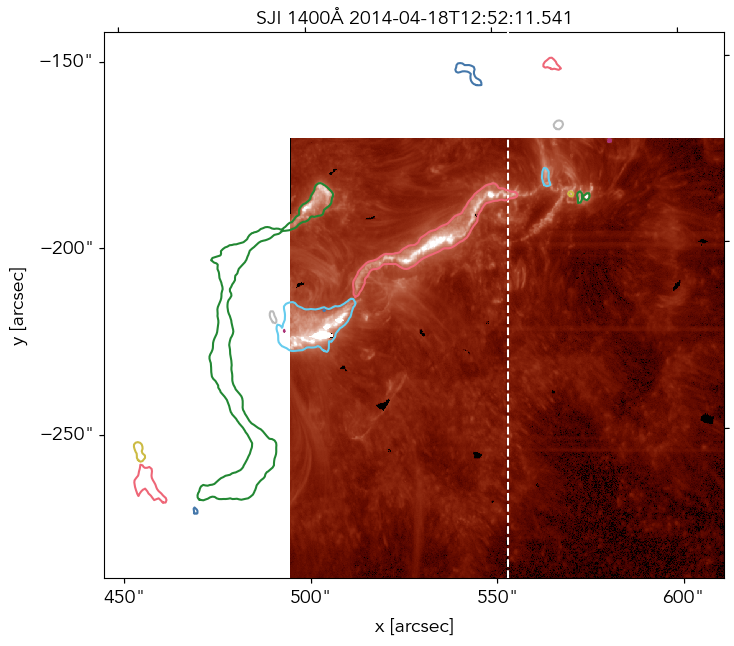

In [13]:
%matplotlib inline

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection=iris_map)
iris_map.plot(axes=ax,norm=LogNorm(vmin=1.0))

ax.coords.grid(False)
ax.set_xlabel('x [arcsec]')
ax.set_ylabel('y [arcsec]')
ax.set_title(f"SJI 1400{chr(197)} {iris_map.date}",fontsize=14)

slit_px = iris_map.meta['crpix1']
ax.axvline(slit_px,color='white',linestyle='dashed')

for r in a_ribbon:
    ax.plot_coord(r)
plt.show()

much better!

finally, save our iris map as a FITS file

In [14]:
date_str = iris_map.date.strftime('%Y%m%dT%H%M%S%f')[:-4]
save_filename = f'SJI_1400_{date_str}_aligned.fits'

#iris_map.save(save_filename,overwrite=True)

In [15]:
save_filename

'SJI_1400_20140418T12521_aligned.fits'